In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import shutil

In [2]:
SAVE_PATH = "processed_data/"  # Dossier où stocker les fichiers
# Supprime tous les fichiers Parquet
#if os.path.exists(SAVE_PATH):
#   shutil.rmtree(SAVE_PATH)  # Supprime tout le dossier

    
os.makedirs(SAVE_PATH, exist_ok=True)

dfs = {}  # Stockage des DataFrames

for user in range(1, 7):  
    for session in range(1, 7):  
        save_file = f"{SAVE_PATH}df_{user}_{session}.parquet"

        # Si le fichier existe déjà, on le charge direct !
        if os.path.exists(save_file):
            print(f"Chargement de {save_file}...")
            dfs[f"df_{user}_{session}"] = pd.read_parquet(save_file)
            continue

        path = f"user_{user}/{user}_{session}/"
        
        # Cherche le fichier JSON
        json_files = [f for f in os.listdir(path) if f.endswith('.json')]
        if not json_files:
            print(f"Aucun fichier JSON trouvé dans {path}")
            continue

        json_path = os.path.join(path, json_files[0])
        with open(json_path, 'r') as f:
            data = json.load(f)

        # Normalisation
        df = pd.json_normalize(data)
        df_motion = pd.json_normalize(data, record_path=['motion'])
        df_orientation = pd.json_normalize(data, record_path=['orientation'])

        # Conversion timestamp UNIX -> datetime
        df_motion['timestamp'] = pd.to_datetime(df_motion['timestamp'], unit='ms')
        df_orientation['timestamp'] = pd.to_datetime(df_orientation['timestamp'], unit='ms')
        df[['createdTS', 'startedTS', 'completionTS']] = df[['createdTS', 'startedTS', 'completionTS']].apply(pd.to_datetime, utc=False)
        
        # strip timezone info
        df['createdTS'] = df['createdTS'].dt.tz_localize(None)
        df['startedTS'] = df['startedTS'].dt.tz_localize(None)
        df['completionTS'] = df['completionTS'].dt.tz_localize(None)
        
        # Filtrage entre startedTS et completionTS
        df_motion = df_motion[(df_motion.timestamp > df.loc[0, 'startedTS']) & (df_motion.timestamp < df.loc[0, 'completionTS'])]
        df_orientation = df_orientation[(df_orientation.timestamp > df.loc[0, 'startedTS']) & (df_orientation.timestamp < df.loc[0, 'completionTS'])]

        # Fusion Motion + Orientation sur timestamp
        df_combined = pd.merge(df_motion, df_orientation, on="timestamp", how="inner")

        # Ajout timestamps relatifs
        df_combined = df_combined.reset_index(drop=True)
        df_combined['relative_timestamp'] = df_combined['timestamp'] - df_combined['timestamp'].iloc[0]
        
        for axis in ['alpha', 'beta', 'gamma']:
            base_value = df_combined[axis].iloc[0]
            for i in range(len(df_combined)):
                if df_combined[axis].iloc[i] > base_value + 50:
                    diff = abs(df_combined[axis].iloc[i] - base_value)
                    df_combined.loc[i:, axis] -= diff
                elif df_combined[axis].iloc[i] < base_value - 50:
                    diff = abs(df_combined[axis].iloc[i] - base_value)
                    df_combined.loc[i:, axis] += diff
                base_value = df_combined[axis].iloc[i]

        

        
        df_combined["sqrt(X²+Y²+Z²)"] = np.sqrt(df_combined["acc.x"]**2 + df_combined["acc.y"]**2 + df_combined["acc.z"]**2)
        df_combined["sqrt(alpha²+beta²+gamma²)"] = np.sqrt(df_combined["alpha"]**2 + df_combined["beta"]**2 + df_combined["gamma"]**2)
        window_size = 10
        df_combined["Moving_Avg"] = df_combined["sqrt(X²+Y²+Z²)"].rolling(window=window_size, min_periods=1).mean()
        df_combined["Moving_Var"] = df_combined["sqrt(X²+Y²+Z²)"].rolling(window=window_size, min_periods=1).var()
        temps_final = df_combined['time_seconds'].max()  # Définir le temps final
        df_combined['time_seconds'] = df_combined['relative_timestamp'].dt.total_seconds()
        df_combined["rotratesitsat"]= np.sqrt(df_combined["rotRate.alpha"]**2 + df_combined["rotRate.beta"]**2)

        # Si c’est le test df_2_2, on ne garde que la plage entre 0 et 30 secondes
        if f"df_{user}_{session}" == "df_2_2":
            df_combined = df_combined[(df_combined['time_seconds'] >= 0) & (df_combined['time_seconds'] <= 30)]

        # Sauvegarde pour éviter de recalculer
        df_combined.to_parquet(save_file)
        print(f"Fichier sauvegardé : {save_file}")

        # Stocker en mémoire si besoin
        dfs[f"df_{user}_{session}"] = df_combined



Chargement de processed_data/df_1_1.parquet...
Chargement de processed_data/df_1_2.parquet...
Chargement de processed_data/df_1_3.parquet...
Chargement de processed_data/df_1_4.parquet...
Chargement de processed_data/df_1_5.parquet...
Chargement de processed_data/df_1_6.parquet...
Chargement de processed_data/df_2_1.parquet...
Chargement de processed_data/df_2_2.parquet...
Chargement de processed_data/df_2_3.parquet...
Chargement de processed_data/df_2_4.parquet...
Chargement de processed_data/df_2_5.parquet...
Chargement de processed_data/df_2_6.parquet...
Chargement de processed_data/df_3_1.parquet...
Chargement de processed_data/df_3_2.parquet...
Chargement de processed_data/df_3_3.parquet...
Chargement de processed_data/df_3_4.parquet...
Chargement de processed_data/df_3_5.parquet...
Chargement de processed_data/df_3_6.parquet...
Chargement de processed_data/df_4_1.parquet...
Chargement de processed_data/df_4_2.parquet...
Chargement de processed_data/df_4_3.parquet...
Chargement de

In [3]:
import math

# Step 1: Find the maximum duration and the global median time step
max_duration = 0
max_len = 0
max_key = None
time_steps = []

for key, df in dfs.items():
    if 'time_seconds' in df.columns:
        current_max = df['time_seconds'].max()
        if current_max > max_duration:
            max_duration = current_max
            max_len = len(df)
            max_time=df.loc[len(df)-1, 'time_seconds']
            max_key = key
        time_steps.append(df['time_seconds'].diff().median())
        
print(f"Test avec le plus grand max duration : '{max_key}' ({max_len} lignes, durée max {max_duration})")
print(max_time)

# Use the global median time step
global_time_step = pd.Series(time_steps).median()
expected_n_points = math.ceil(max_duration / global_time_step)

# Step 2: Complete each DataFrame up to *expected\_n\_points*
sensor_cols = ['alpha', 'beta', 'gamma', 
               'acc.x', 'acc.y', 'acc.z', 
               'rotRate.alpha', 'rotRate.beta', 'rotRate.gamma']

for key, df in dfs.items():
    if 'time_seconds' not in df.columns:
        continue

    current_n = len(df)
    n_to_add = expected_n_points - current_n
    if n_to_add > 0:
        last_time = df['time_seconds'].iloc[-1]
        new_times = [last_time + global_time_step * (i + 1) for i in range(n_to_add)]
        new_data = {'time_seconds': new_times}

        for col in sensor_cols:
            new_data[col] = [0.0] * n_to_add
        for col in df.columns:
            if col not in new_data:
                new_data[col] = [df[col].iloc[-1]] * n_to_add

        df_to_add = pd.DataFrame(new_data)
        dfs[key] = pd.concat([df, df_to_add], ignore_index=True)


Test avec le plus grand max duration : 'df_6_6' (1622 lignes, durée max 39.847)
39.847


In [4]:
import numpy as np

for key, df in dfs.items():
    # Vérification basique
    if 'rotRate.alpha' not in df.columns or 'beta' not in df.columns:
        continue

  
    df["msFromStart"]=df["time_seconds"]*1000
  
    dfs[key] = df


In [5]:
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path

base_path = Path("tugt_for_students")
attachments_path = base_path / "attachments" / "1"
excel_path = base_path / "UserKeys-Participants.xlsx"
results_path = base_path / "filtered_taskresults"
output_dir = base_path / "processed_data"
output_dir.mkdir(exist_ok=True)

# === Étape 1 : Charger correspondance userKey → patient_X ===
user_keys = pd.read_excel(excel_path)

user_id_to_patient = {}
for _, row in user_keys.iterrows():
    patient_id = f"patient_{int(row['N'])}"
    for key in ['userKey', 'Additional userKey']:
        if pd.notna(row[key]):
            try:
                user_id_cleaned = str(int(row[key]))
                user_id_to_patient[user_id_cleaned] = patient_id
            except:
                continue

# === Étape 2 : Charger les taskresults dans un dict (userKey, attachment) → createdTS
taskresult_info = {}
for result_file in results_path.glob("*.json"):
    try:
        with open(result_file, "r") as f:
            data = json.load(f)
            user_key = str(int(data["userKey"]))
            attachments = data.get("attachments", [])
            createdTS = data.get("createdTS") or data.get("summary", {}).get("startedTS")
            if not createdTS or not attachments:
                continue
            dt = datetime.fromisoformat(createdTS.replace("Z", "+00:00"))
            for attachment in attachments:
                taskresult_info[(user_key, attachment)] = dt
    except Exception as e:
        print(f"[⚠️] Erreur taskresult {result_file.name}: {e}")

# === Étape 3 : Extraire, nettoyer et stocker les tests
tests_par_patient = {}

for user_id in os.listdir(attachments_path):
    user_folder = attachments_path / user_id
    if not user_folder.is_dir():
        continue

    try:
        cleaned_user_id = str(int(user_id))
    except:
        cleaned_user_id = user_id.strip()

    patient_name = user_id_to_patient.get(cleaned_user_id)
    if not patient_name:
        print(f"❓ Utilisateur {user_id} non trouvé dans le fichier Excel.")
        continue

    for test_file in os.listdir(user_folder):
        if not test_file.endswith(".json"):
            continue

        test_path = user_folder / test_file

        try:
            with open(test_path, 'r') as f:
                test_data = json.load(f)
        except Exception as e:
            print(f"❌ Erreur lecture JSON pour {test_file} : {e}")
            continue

        if 'motion' not in test_data or 'orientation' not in test_data:
            print(f"⛔ Fichier {test_file} ignoré : pas de motion/orientation.")
            continue

        try:
            df_motion = pd.json_normalize(test_data['motion'])
            df_orientation = pd.json_normalize(test_data['orientation'])
        except Exception as e:
            print(f"❌ Erreur parsing motion/orientation : {e}")
            continue

        if all(col in df_motion.columns for col in ["acc.x", "acc.y", "acc.z"]):
            df_motion["sqrt(X²+Y²+Z²)"] = np.sqrt(
                df_motion["acc.x"]**2 + df_motion["acc.y"]**2 + df_motion["acc.z"]**2
            )
        else:
            print(f"⛔ Colonnes acc manquantes dans {test_file}, on ignore ce test.")
            continue

        df_orientation["betagamma"] = np.sqrt(df_orientation["beta"]**2 + df_orientation["gamma"]**2)
        df_motion["rotratesitsat"] = np.sqrt(df_motion["rotRate.alpha"]**2 + df_motion["rotRate.beta"]**2)

        df_combined = pd.merge_asof(
            df_motion, df_orientation,
            on="msFromStart", direction="nearest", tolerance=10
        ).reset_index(drop=True)

        # Correction des sauts alpha/beta/gamma
        for angle in ['alpha', 'beta', 'gamma']:
            base = df_combined[angle].iloc[0]
            for i in range(len(df_combined)):
                val = df_combined[angle].iloc[i]
                if val > base + 100:
                    df_combined.loc[i:, angle] -= abs(val - base)
                elif val < base - 100:
                    df_combined.loc[i:, angle] += abs(val - base)
                base = df_combined[angle].iloc[i]

        df_combined["betagamma"] = np.sqrt(df_combined["beta"]**2 + df_combined["gamma"]**2)

        # Obtenir la date de création via taskresult
        created_dt = taskresult_info.get((cleaned_user_id, test_file))
        if not created_dt:
            print(f"⚠️ Pas de taskresult pour {patient_name}, fichier {test_file}")
            continue

        tests_par_patient.setdefault(patient_name, []).append(
            (created_dt, df_combined, test_file)
        )

# === Étape 4 : Sauvegarder trié dans l’ordre temporel
dfs2 = {}

for patient, tests in tests_par_patient.items():
    tests_sorted = sorted(tests, key=lambda x: x[0])  # Sort by createdTS

    for idx, (dt, df, original_name) in enumerate(tests_sorted, start=1):
        output_filename = f"{patient}_test_{idx}.parquet"
        output_path = output_dir / output_filename
        df.to_parquet(output_path, index=False)
        dfs2[f"{patient}_test_{idx}"] = df
        print(f"✅ {output_filename} sauvegardé ({original_name} @ {dt.isoformat()})")


❓ Utilisateur 34221590 non trouvé dans le fichier Excel.
⛔ Colonnes acc manquantes dans 38229404.json, on ignore ce test.
⛔ Colonnes acc manquantes dans 40790328.json, on ignore ce test.
⛔ Colonnes acc manquantes dans 39294883.json, on ignore ce test.
❓ Utilisateur 39790608 non trouvé dans le fichier Excel.
⛔ Colonnes acc manquantes dans 43487989.json, on ignore ce test.
⛔ Colonnes acc manquantes dans 48234516.json, on ignore ce test.
✅ patient_1_test_1.parquet sauvegardé (35254651.json @ 2022-12-07T08:09:05.755000+00:00)
✅ patient_1_test_2.parquet sauvegardé (38554653.json @ 2023-02-07T11:05:35.875000+00:00)
✅ patient_2_test_1.parquet sauvegardé (35580718.json @ 2022-12-13T11:28:51.009000+00:00)
✅ patient_2_test_2.parquet sauvegardé (35788581.json @ 2022-12-17T09:28:26.467000+00:00)
✅ patient_2_test_3.parquet sauvegardé (35849923.json @ 2022-12-18T13:12:02.681000+00:00)
✅ patient_2_test_4.parquet sauvegardé (35959195.json @ 2022-12-20T14:33:06.601000+00:00)
✅ patient_2_test_5.parquet 

✅ patient_13_test_2.parquet sauvegardé (45308241.json @ 2023-06-14T10:01:31.036000+00:00)
✅ patient_14_test_1.parquet sauvegardé (42654273.json @ 2023-04-25T12:50:16.407000+00:00)
✅ patient_14_test_2.parquet sauvegardé (42711539.json @ 2023-04-26T14:37:23.462000+00:00)
✅ patient_15_test_1.parquet sauvegardé (43019325.json @ 2023-05-02T09:40:42.501000+00:00)
✅ patient_15_test_2.parquet sauvegardé (43060613.json @ 2023-05-03T04:19:30.029000+00:00)
✅ patient_15_test_3.parquet sauvegardé (43060683.json @ 2023-05-03T04:21:07.854000+00:00)
✅ patient_15_test_4.parquet sauvegardé (43115979.json @ 2023-05-04T05:17:40.424000+00:00)
✅ patient_15_test_5.parquet sauvegardé (43167736.json @ 2023-05-05T04:41:25.929000+00:00)
✅ patient_15_test_6.parquet sauvegardé (43755786.json @ 2023-05-16T06:32:47.727000+00:00)
✅ patient_15_test_7.parquet sauvegardé (44343759.json @ 2023-05-27T07:17:09.222000+00:00)
✅ patient_17_test_1.parquet sauvegardé (43761987.json @ 2023-05-16T09:15:38.142000+00:00)
✅ patient_

In [6]:
test_boundaries2 = {
    'patient_1_test_1': {'start': 21385, 'end': 31951},
    'patient_1_test_2': {'start': 14336, 'end': 25653},
    'patient_2_test_8': {'start': 9798, 'end': 16980},
    'patient_3_test_1': {'start': 14048, 'end': 25131},
    'patient_4_test_8': {'start': 34966, 'end': 46499},
    'patient_5_test_1': {'start': 13208, 'end': 19975},
    'patient_5_test_3': {'start': 11335, 'end': 17402},
    'patient_6_test_1': {'start': 22212, 'end': 33462},
    'patient_6_test_3': {'start': 9058, 'end': 18241},
    'patient_7_test_2': {'start': 7854, 'end': 18754},
    'patient_8_test_1': {'start': 6711, 'end': 15443},
    'patient_9_test_1': {'start': 11502, 'end': 19487},
    'patient_9_test_2': {'start': 5515, 'end': 13798},
    'patient_10_test_59': {'start': 11669, 'end': 21035},
    'patient_12_test_1': {'start': 6715, 'end': 19931},
    'patient_12_test_2': {'start': 8380, 'end': 18514},
    'patient_13_test_2': {'start': 11585, 'end': 21219},
    'patient_14_test_1': {'start': 30125, 'end': 45292},
    'patient_15_test_1': {'start': 12992, 'end': 27675},
    'patient_16_test_1': {'start': 4380, 'end': 17297},
    'patient_17_test_3': {'start': 8523, 'end': 16707},
    'patient_18_test_1': {'start': 11708, 'end': 21459},
    'patient_20_test_1': {'start': 15234, 'end': 28150},
    'patient_21_test_1': {'start': 11498, 'end': 20864},
    'patient_21_test_2': {'start': 18553, 'end': 28285},
    'patient_24_test_1': {'start': 10883, 'end': 25067},
    'patient_25_test_3': {'start': 11019, 'end': 25502},
    'patient_26_test_1': {'start': 11085, 'end': 21935},
    'patient_26_test_2': {'start': 11336, 'end': 20669},
    'patient_27_test_1': {'start': 22668, 'end': 33536},
    'patient_29_test_1': {'start': 12635, 'end': 20918}
}


In [7]:
# Nouvelle bibliothèque pour stocker uniquement les tests valides
dfs3 = {}

# Application de is_test dans les dfs2, et ajout à dfs3 si applicable
for test_id, bounds in test_boundaries2.items():
    start = bounds["start"]
    end = bounds["end"]

    # Vérifie que les bornes ne sont pas None et que le DataFrame existe dans dfs2
    if start is not None and end is not None and test_id in dfs2:
        df = dfs2[test_id].copy()

        # Marquage dans une nouvelle colonne "is_test"
        df["is_test"] = ((df["msFromStart"] >= start) & (df["msFromStart"] <= end)).astype(int)

        # Ajout du DataFrame modifié à dfs3
        dfs3[test_id] = df
    else:
        print(f"⚠️ Skipped {test_id} (missing bounds or DataFrame)")


In [8]:
test_boundaries = {
    'df_1_1': {'start': 240, 'end': 589},
    'df_1_2': {'start': 270, 'end': 530},
    'df_1_3': {'start': 127, 'end': 319},
    'df_1_4': {'start': 83, 'end': 293},
    'df_1_5': {'start': 105, 'end': 522},
    'df_1_6': {'start': 166, 'end': 677},
    
    'df_2_1': {'start': 188, 'end': 318},
    'df_2_2': {'start': 160, 'end': 384},
    'df_2_3': {'start': 126, 'end': 328},
    'df_2_4': {'start': 188, 'end': 357},
    'df_2_5': {'start': 220, 'end': 778},
    'df_2_6': {'start': 142, 'end': 961},

    'df_3_1': {'start': 277, 'end': 582},
    'df_3_2': {'start': 120, 'end': 286},
    'df_3_3': {'start': 183, 'end': 464},
    'df_3_4': {'start': 156, 'end': 650},
    'df_3_5': {'start': 132, 'end': 312},
    'df_3_6': {'start': 249, 'end': 734},

    'df_4_1': {'start': 353, 'end': 946},
    'df_4_2': {'start': 324, 'end': 667},
    'df_4_3': {'start': 246, 'end': 640},
    'df_4_4': {'start': 233, 'end': 905},
    'df_4_5': {'start': 264, 'end': 529},
    'df_4_6': {'start': 201, 'end': 916},

    'df_5_1': {'start': 351, 'end': 715},
    'df_5_2': {'start': 211, 'end': 428},
    'df_5_3': {'start': 160, 'end': 381},
    'df_5_4': {'start': None, 'end': None},
    'df_5_5': {'start': 123, 'end': 640},
    'df_5_6': {'start': 165, 'end': 955},

    'df_6_1': {'start': 200, 'end': 513},
    'df_6_2': {'start': 195, 'end': 577},
    'df_6_3': {'start': 120, 'end': 388},
    'df_6_4': {'start': 200, 'end': 434},
    'df_6_5': {'start': 285, 'end': 1171},
    'df_6_6': {'start': 320, 'end': 1464},
}


In [9]:
for key, df in dfs.items():
    bounds = test_boundaries.get(key, None)
    if bounds is None:
        df["is_test"] = 0
        continue

    start = bounds["start"]
    end = bounds["end"]
    
    df["is_test"] = 0
    df.loc[start:end, "is_test"] = 1

    dfs[key] = df


for key, df in dfs.items():
    df.to_csv(f"annotated_data/{key}.csv", index=False)


In [10]:
for key, df in dfs.items():
    nb_points = len(df)
    print(f"{key} : {nb_points} points")
    print(df.loc[len(df)-1, 'time_seconds'])


df_1_1 : 2277 points
53.05450000000157
df_1_2 : 2277 points
55.83850000000159
df_1_3 : 2277 points
48.89050000000177
df_1_4 : 2277 points
45.64150000000181
df_1_5 : 2277 points
49.273500000001604
df_1_6 : 2277 points
56.85900000000145
df_2_1 : 2277 points
62.200000000001836
df_2_2 : 2277 points
59.26000000000161
df_2_3 : 2277 points
51.597000000001685
df_2_4 : 2277 points
52.11950000000179
df_2_5 : 2277 points
59.40200000000139
df_2_6 : 2277 points
57.892000000001204
df_3_1 : 2277 points
60.219500000001574
df_3_2 : 2277 points
47.338000000001806
df_3_3 : 2277 points
47.490500000001674
df_3_4 : 2277 points
51.2040000000015
df_3_5 : 2277 points
48.72050000000185
df_3_6 : 2277 points
63.067500000001424
df_4_1 : 2277 points
46.19000000000118
df_4_2 : 2277 points
45.609000000001444
df_4_3 : 2277 points
46.061000000001485
df_4_4 : 2277 points
48.49650000000122
df_4_5 : 2277 points
44.71800000000157
df_4_6 : 2277 points
47.184500000001194
df_5_1 : 2277 points
46.85500000000144
df_5_2 : 2277 p

In [11]:
def hybrid_is_test_filter(is_test_array, window_size=50):
    n = len(is_test_array)
    votes = np.zeros(n)
    counts = np.zeros(n)

    for start in range(0, n - window_size + 1):
        end = start + window_size
        window = is_test_array[start:end]
        label = int(np.mean(window) >= 0.5)

        votes[start:end] += label  # Ajouter le label à chaque point de la fenêtre
        counts[start:end] += 1     # Compter combien de fois le point a été visité

    final_votes = votes / counts
    return (final_votes >= 0.5).astype(int)


In [12]:
# Ajout de la colonne patient_id dans dfs
for patient_id, df in dfs.items():
    df["patient_id"] = patient_id

# Idem pour dfs3
for patient_id, df in dfs3.items():
    df["patient_id"] = patient_id

# Maintenant concatène tous les dfs
all_dfs = list(dfs.values()) + list(dfs3.values())
df_all = pd.concat(all_dfs, ignore_index=True)


Train: (3733, 50, 9), Val: (864, 50, 9), Test: (968, 50, 9)
Train % test labels: 0.276, Val: 0.225, Test: 0.236
Class weights: {0: 0.6910403554239171, 1: 1.808624031007752}


C:\Users\Simon Guillet\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7225 - loss: 0.5858 - val_accuracy: 0.9421 - val_loss: 0.4666
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8731 - loss: 0.3587 - val_accuracy: 0.8681 - val_loss: 0.3538
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8981 - loss: 0.3284 - val_accuracy: 0.9005 - val_loss: 0.2663
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9043 - loss: 0.2923 - val_accuracy: 0.9259 - val_loss: 0.2972
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9120 - loss: 0.2826 - val_accuracy: 0.9167 - val_loss: 0.2914
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9265 - loss: 0.2744 - val_accuracy: 0.9236 - val_loss: 0.2214
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9371 - loss: 0.2301 - val_accuracy: 0.9363 - val_loss: 0.2382
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9202 - loss: 0.2729 - val_accuracy: 0.9433 - 

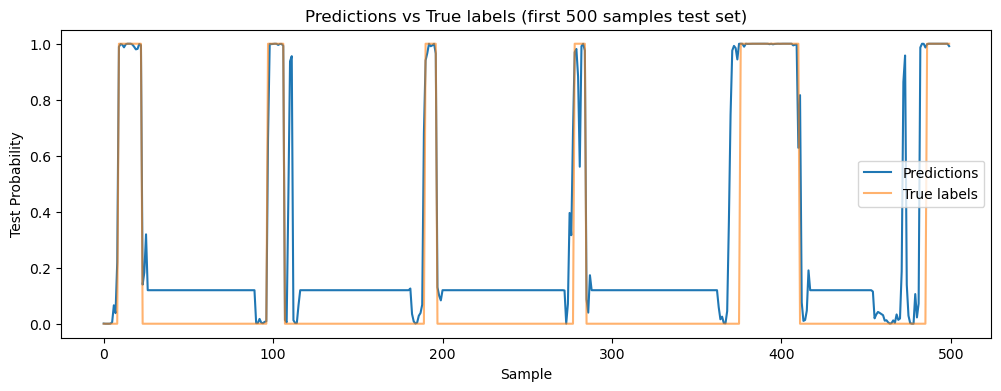

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D

#\=== 1. Concatenate all DataFrames without distinction between dfs / dfs3 ===

# dfs and dfs3 are dictionaries of DataFrames per patient


all_dfs = list(dfs.values()) + list(dfs3.values())
df_all = pd.concat(all_dfs, ignore_index=True)

# === 2. Feature scaling ===
features = ['acc.x', 'acc.y', 'acc.z',
            'rotRate.alpha', 'rotRate.beta', 'rotRate.gamma',
            'alpha', 'beta', 'gamma']

scaler = StandardScaler()
signals_scaled = scaler.fit_transform(df_all[features])

# === 3. Filtrage test avec ta fonction hybride ===
df_all["is_test_filtered"] = hybrid_is_test_filter(df_all["is_test"].values, window_size=50)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df_all_imputed = df_all.copy()
df_all[features] = imputer.fit_transform(df_all_imputed[features])
signals_scaled = scaler.fit_transform(df_all[features])


# === 4. Fenêtrage des données ===
sampling_rate = 50
window_size = sampling_rate
step = window_size // 2  # 50% overlap

X = []
y = []
# Recréer window_patient_ids en même temps que X et y
window_patient_ids = []

for start in range(0, len(df_all) - window_size + 1, step):
    end = start + window_size
    window = signals_scaled[start:end]
    label = int(df_all["is_test_filtered"].iloc[start:end].mean() >= 0.5)
    X.append(window)
    y.append(label)
    
    # Ajoute l'identifiant du patient pour cette fenêtre
    window_patient_ids.append(df_all["patient_id"].iloc[start])

# Convertir en arrays numpy
X = np.array(X)
y = np.array(y)
window_patient_ids = np.array(window_patient_ids)

# === 5. Train/val/test split by patient (70/15/15) ===

unique_patients = np.unique(window_patient_ids)
train_patients, temp_patients = train_test_split(unique_patients, test_size=0.3, random_state=42)
val_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=42)

train_mask = np.isin(window_patient_ids, train_patients)
val_mask = np.isin(window_patient_ids, val_patients)
test_mask = np.isin(window_patient_ids, test_patients)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train % test labels: {np.mean(y_train):.3f}, Val: {np.mean(y_val):.3f}, Test: {np.mean(y_test):.3f}")

#\=== 6. Class weights ===

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(cw)}
print(f"Class weights: {class_weights}")

# === 7. Unchanged CNN model ===

model = Sequential([
    Conv1D(64, kernel_size=5, activation='relu', padding='same', input_shape=(window_size, X.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(patience=5, restore_best_weights=True)

# === 8. Training with explicit validation set ===

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# === 9. Évaluation finale sur test ===
loss, acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {acc:.3f}")

# === 10. Visualisation des prédictions sur test ===
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_pred[:500], label='Predictions')
plt.plot(y_test[:500], label='True labels', alpha=0.6)
plt.xlabel('Sample')
plt.ylabel('Test Probability')
plt.legend()
plt.title('Predictions vs True labels (first 500 samples test set)')
plt.show()


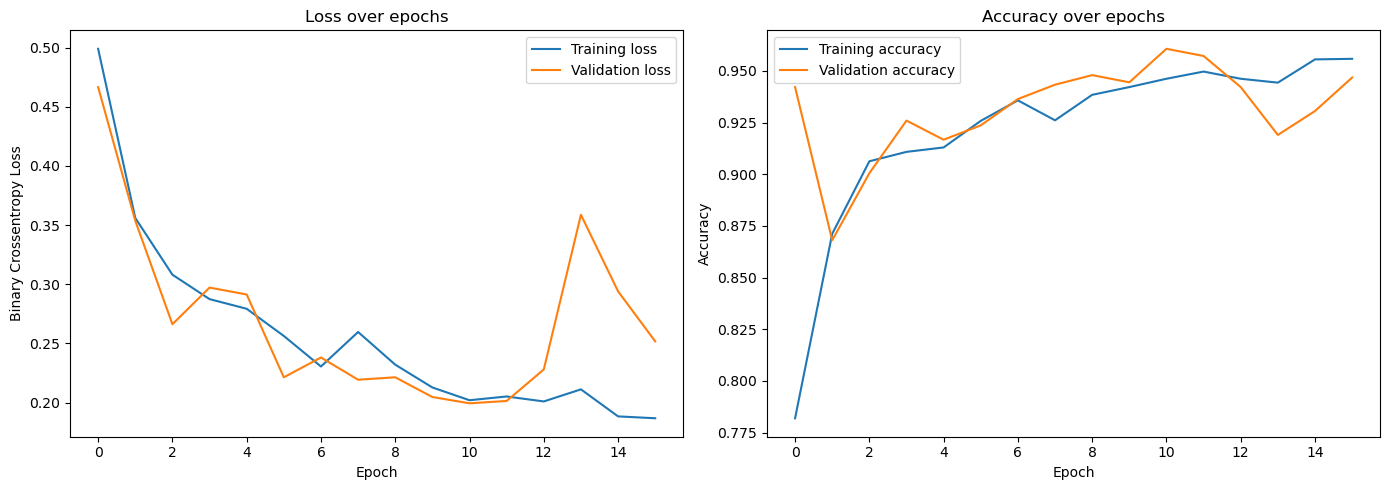

In [14]:
# === 11. Courbes de loss et d'accuracy ===
plt.figure(figsize=(14, 5))

# Courbe de loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()

# Courbe d'accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 12, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,749 (1.65 MB)

 Trainable params: 143,617 (561.00 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 287,236 (1.10 MB)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


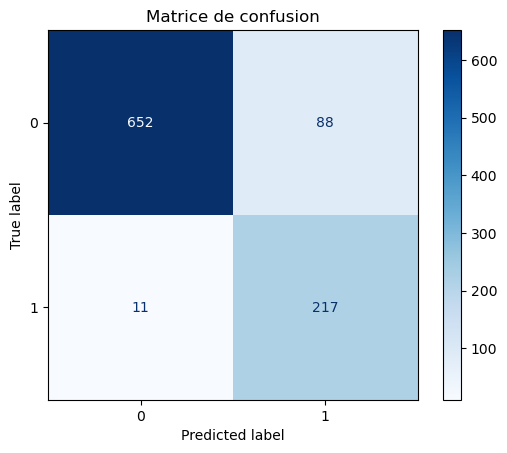

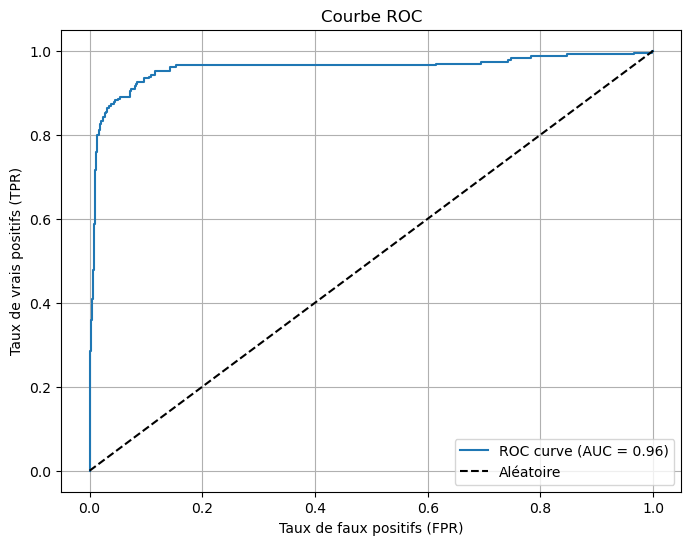

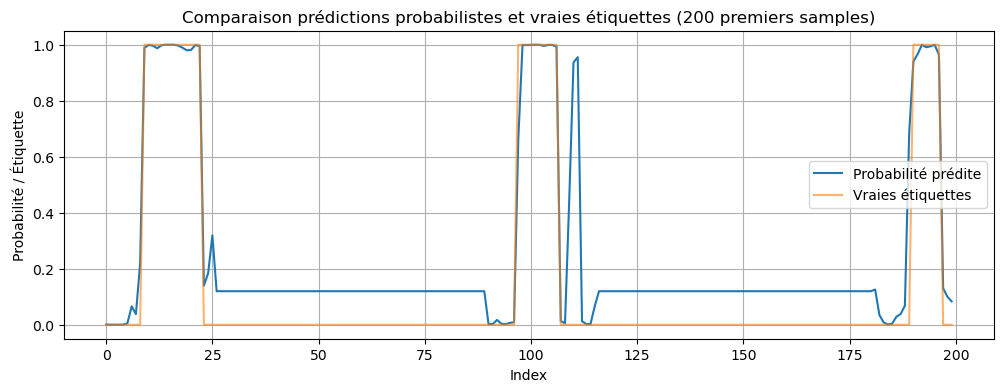

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Prédictions probabilistes
y_pred_proba = model.predict(X_test).flatten()

# Classes prédites avec seuil 0.5
y_pred_class = (y_pred_proba >= 0.5).astype(int)

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()

# 2. Courbe ROC et AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend()
plt.grid()
plt.show()

# 3. Comparaison prédictions et vraies classes (sur les 200 premiers samples)
plt.figure(figsize=(12, 4))
plt.plot(y_pred_proba[:200], label='Probabilité prédite')
plt.plot(y_test[:200], label='Vraies étiquettes', alpha=0.6)
plt.xlabel('Index')
plt.ylabel('Probabilité / Étiquette')
plt.title("Comparaison prédictions probabilistes et vraies étiquettes (200 premiers samples)")
plt.legend()
plt.grid()
plt.show()


In [17]:
# 1. Extraire colonnes
df_name="patient_26_test_1"
#6_6 6_5 3_4 3_6
df = dfs2[df_name]
cols = ['acc.x', 'acc.y', 'acc.z', 'rotRate.alpha', 'rotRate.beta', 'rotRate.gamma', 'alpha', 'beta', 'gamma']
X = df[cols].values

# 2. Normaliser (avec scaler déjà entraîné)
X_scaled = scaler.transform(X)

# 3. Découper en fenêtres
window_size = 50
windows = []
for start in range(0, len(X_scaled) - window_size + 1, window_size):
    windows.append(X_scaled[start:start+window_size])
X_windows = np.array(windows)

# 4. Prédire
preds = model.predict(X_windows)
labels_pred = (preds > 0.5).astype(int)

# 5. Afficher résultats
for i, label in enumerate(labels_pred):
    print(f"Fenêtre {i} : {'TEST' if label == 1 else 'PAS TEST'}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Fenêtre 0 : PAS TEST
Fenêtre 1 : PAS TEST
Fenêtre 2 : PAS TEST
Fenêtre 3 : PAS TEST
Fenêtre 4 : PAS TEST
Fenêtre 5 : PAS TEST
Fenêtre 6 : PAS TEST
Fenêtre 7 : PAS TEST
Fenêtre 8 : PAS TEST
Fenêtre 9 : PAS TEST
Fenêtre 10 : PAS TEST
Fenêtre 11 : PAS TEST
Fenêtre 12 : PAS TEST
Fenêtre 13 : TEST
Fenêtre 14 : TEST
Fenêtre 15 : TEST
Fenêtre 16 : TEST
Fenêtre 17 : TEST
Fenêtre 18 : TEST
Fenêtre 19 : TEST
Fenêtre 20 : TEST
Fenêtre 21 : TEST
Fenêtre 22 : TEST
Fenêtre 23 : TEST
Fenêtre 24 : TEST
Fenêtre 25 : TEST
Fenêtre 26 : TEST
Fenêtre 27 : PAS TEST
Fenêtre 28 : PAS TEST
Fenêtre 29 : PAS TEST
Fenêtre 30 : PAS TEST
Fenêtre 31 : PAS TEST
Fenêtre 32 : PAS TEST
Fenêtre 33 : PAS TEST
Fenêtre 34 : PAS TEST
Fenêtre 35 : PAS TEST
Fenêtre 36 : PAS TEST
Fenêtre 37 : PAS TEST
Fenêtre 38 : PAS TEST
Fenêtre 39 : PAS TEST
Fenêtre 40 : PAS TEST
Fenêtre 41 : PAS TEST
Fenêtre 42 : PAS TEST


C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
import numpy as np

def smooth_short_test_blocks(labels_pred, max_block_size=4):
    labels_pred = np.array(labels_pred).copy()
    smoothed = labels_pred.copy()
    i = 0

    while i < len(labels_pred):
        if labels_pred[i] == 1:
            start = i
            while i < len(labels_pred) and labels_pred[i] == 1:
                i += 1
            end = i  # bloc de [start, end-1]

            block_size = end - start
            if block_size <= max_block_size:
                # Vérifie qu'on est entouré de 0
                left_ok = start - 1 >= 0 and labels_pred[start - 1] == 0
                right_ok = end < len(labels_pred) and labels_pred[end] == 0
                if left_ok and right_ok:
                    smoothed[start:end] = 0
        else:
            i += 1

    return smoothed
labels_pred_smooth = smooth_short_test_blocks(labels_pred, max_block_size=4)

# Affichage
for i, label in enumerate(labels_pred_smooth):
    print(f"Fenêtre {i} : {'TEST' if label == 1 else 'PAS TEST'}")


Fenêtre 0 : PAS TEST
Fenêtre 1 : PAS TEST
Fenêtre 2 : PAS TEST
Fenêtre 3 : PAS TEST
Fenêtre 4 : PAS TEST
Fenêtre 5 : PAS TEST
Fenêtre 6 : PAS TEST
Fenêtre 7 : PAS TEST
Fenêtre 8 : PAS TEST
Fenêtre 9 : PAS TEST
Fenêtre 10 : PAS TEST
Fenêtre 11 : PAS TEST
Fenêtre 12 : PAS TEST
Fenêtre 13 : TEST
Fenêtre 14 : TEST
Fenêtre 15 : TEST
Fenêtre 16 : TEST
Fenêtre 17 : TEST
Fenêtre 18 : TEST
Fenêtre 19 : TEST
Fenêtre 20 : TEST
Fenêtre 21 : TEST
Fenêtre 22 : TEST
Fenêtre 23 : TEST
Fenêtre 24 : TEST
Fenêtre 25 : TEST
Fenêtre 26 : TEST
Fenêtre 27 : PAS TEST
Fenêtre 28 : PAS TEST
Fenêtre 29 : PAS TEST
Fenêtre 30 : PAS TEST
Fenêtre 31 : PAS TEST
Fenêtre 32 : PAS TEST
Fenêtre 33 : PAS TEST
Fenêtre 34 : PAS TEST
Fenêtre 35 : PAS TEST
Fenêtre 36 : PAS TEST
Fenêtre 37 : PAS TEST
Fenêtre 38 : PAS TEST
Fenêtre 39 : PAS TEST
Fenêtre 40 : PAS TEST
Fenêtre 41 : PAS TEST
Fenêtre 42 : PAS TEST


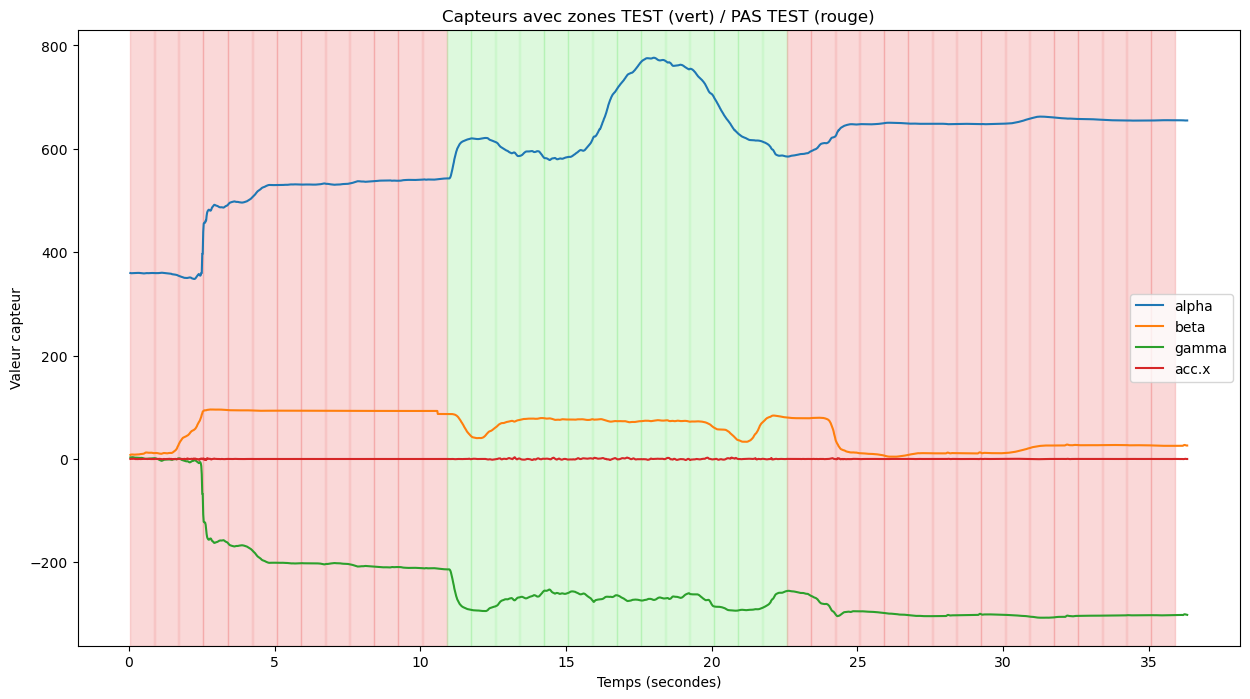

In [19]:
import matplotlib.pyplot as plt
import numpy as np

cols_to_plot = ['alpha', 'beta', 'gamma', 'acc.x']
df['time_seconds']=df['msFromStart']*0.001
time = df['time_seconds'].values

plt.figure(figsize=(15, 8))

# Tracer les courbes des capteurs
for col in cols_to_plot:
    plt.plot(time, df[col], label=col)

window_size = 50

# Colorier les zones selon labels_pred, en évitant les débordements d'indices
for i, label in enumerate(labels_pred):
    start_idx = i * window_size
    end_idx = start_idx + window_size

    # Si start_idx dépasse la longueur de time, on arrête la boucle
    if start_idx >= len(time):
        break
    
    # Ajuster end_idx pour ne pas dépasser la taille de time
    if end_idx > len(time):
        end_idx = len(time)
    
    # Si la fenêtre n'est plus valide (rare), on saute
    if start_idx >= end_idx:
        continue

    color = 'lightgreen' if label == 1 else 'lightcoral'
    plt.axvspan(time[start_idx], time[end_idx - 1], color=color, alpha=0.3)

plt.xlabel('Temps (secondes)')
plt.ylabel('Valeur capteur')
plt.title('Capteurs avec zones TEST (vert) / PAS TEST (rouge)')
plt.legend()
plt.show()


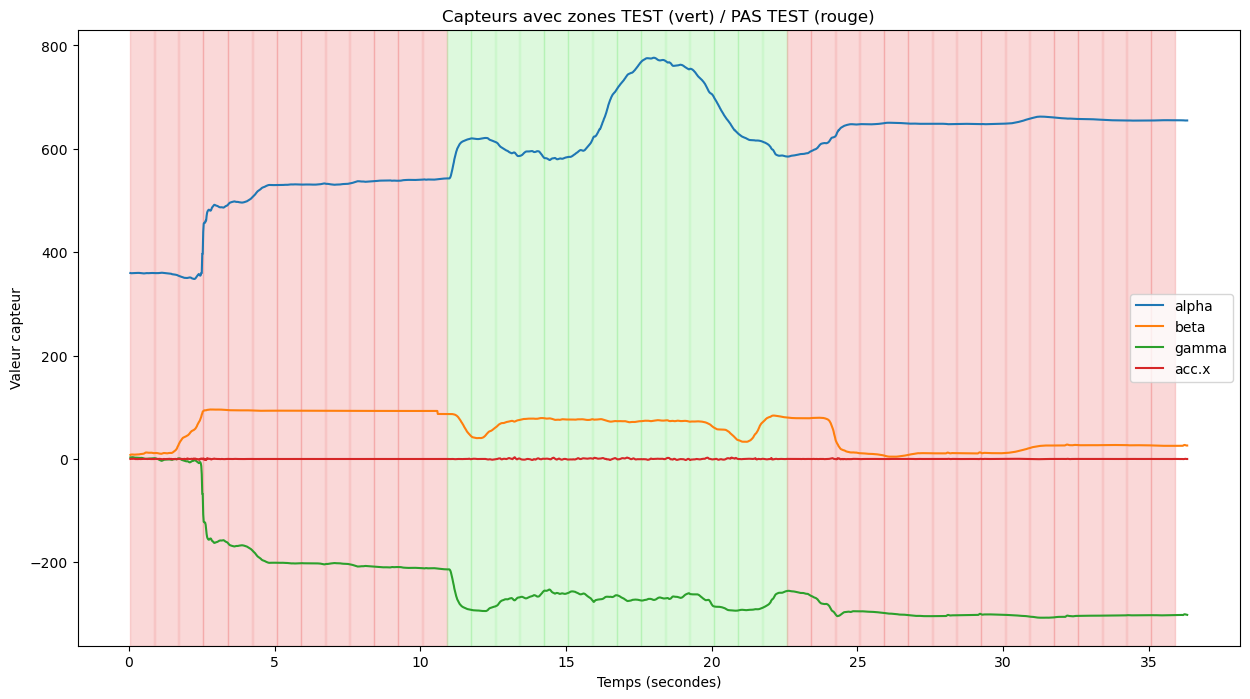

In [20]:
import matplotlib.pyplot as plt
import numpy as np

cols_to_plot = ['alpha', 'beta', 'gamma', 'acc.x']

time = df['time_seconds'].values

plt.figure(figsize=(15, 8))

# Tracer les courbes des capteurs
for col in cols_to_plot:
    plt.plot(time, df[col], label=col)

window_size = 50

# Colorier les zones selon labels_pred, en évitant les débordements d'indices
for i, label in enumerate(labels_pred_smooth):
    start_idx = i * window_size
    end_idx = start_idx + window_size

    # Si start_idx dépasse la longueur de time, on arrête la boucle
    if start_idx >= len(time):
        break
    
    # Ajuster end_idx pour ne pas dépasser la taille de time
    if end_idx > len(time):
        end_idx = len(time)
    
    # Si la fenêtre n'est plus valide (rare), on saute
    if start_idx >= end_idx:
        continue

    color = 'lightgreen' if label == 1 else 'lightcoral'
    plt.axvspan(time[start_idx], time[end_idx - 1], color=color, alpha=0.3)

plt.xlabel('Temps (secondes)')
plt.ylabel('Valeur capteur')
plt.title('Capteurs avec zones TEST (vert) / PAS TEST (rouge)')
plt.legend()
plt.show()


In [21]:
resultats_tests = []
temps_tests = []
temps_tests2 =[]
for key, df in dfs2.items():
   # 1. Extraire colonnes
    cols = ['acc.x', 'acc.y', 'acc.z', 'rotRate.alpha', 'rotRate.beta', 'rotRate.gamma', 'alpha', 'beta', 'gamma']
    X = df[cols].values

    # 2. Normaliser (avec scaler déjà entraîné)
    X_scaled = scaler.transform(X)

    # 3. Découper en fenêtres
    window_size = 50
    windows = []
    for start in range(0, len(X_scaled) - window_size + 1, window_size):
        windows.append(X_scaled[start:start+window_size])
    X_windows = np.array(windows)
    if X_windows.shape[0] == 0:
        print(f"Pas assez de données pour {key}, skipping.")
        continue
    # 4. Prédire
    preds = model.predict(X_windows)
    labels_pred = (preds > 0.5).astype(int)
    labels_pred_smooth = labels_pred.copy()

    import numpy as np

    def smooth_short_test_blocks(labels_pred, max_block_size=4):
        labels_pred = np.array(labels_pred).copy()
        smoothed = labels_pred.copy()
        i = 0

        while i < len(labels_pred):
            if labels_pred[i] == 1:
                start = i
                while i < len(labels_pred) and labels_pred[i] == 1:
                    i += 1
                end = i  # bloc de [start, end-1]

                block_size = end - start
                if block_size <= max_block_size:
                    # Vérifie qu'on est entouré de 0
                    left_ok = start - 1 >= 0 and labels_pred[start - 1] == 0
                    right_ok = end < len(labels_pred) and labels_pred[end] == 0
                    if left_ok and right_ok:
                        smoothed[start:end] = 0
            else:
                i += 1

        return smoothed
    labels_pred_smooth = smooth_short_test_blocks(labels_pred, max_block_size=4)


     # 5. Trouver indices des tests détectés
    test_indices = np.where(labels_pred_smooth == 1)[0]

    if len(test_indices) > 0:
        first_window_index = test_indices[0]
        last_window_index = test_indices[-1]

        # Convertir les indices de fenêtres en indices de lignes dans df
        start_idx = first_window_index * window_size
        end_idx = (last_window_index + 1) * window_size - 1  # fin exclusive, donc on recule d'un pas

        # S'assurer de ne pas dépasser la taille du dataframe
        end_idx = min(end_idx, len(df) - 1)

        start_time = df.iloc[start_idx]['msFromStart']
        end_time = df.iloc[end_idx]['msFromStart']
        
        message = f"Test détecté pour {key} de {start_time:.2f}s à {end_time:.2f}s"
        message2 =  (end_time-start_time)*0.001
        message3 = f"Test détecté pour {key} dure {(end_time-start_time)*0.001}s"
    else:
        message = f"Aucun test détecté pour {key}"
        message2 = np.nan  # ou float('nan')
        message3 = np.nan
    resultats_tests.append(message)
    temps_tests.append(message2)
    temps_tests2.append(message3)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


...

C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Pas assez de données pour patient_28_test_1, skipping.


C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


C:\Users\Simon Guillet\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
for msg in resultats_tests:
    print(msg)

Test détecté pour patient_1_test_1 de 20919.00s à 31735.00s
Test détecté pour patient_1_test_2 de 14170.00s à 26653.00s
Test détecté pour patient_2_test_1 de 11709.00s à 22526.00s
Test détecté pour patient_2_test_2 de 12368.00s à 21518.00s
Test détecté pour patient_2_test_3 de 6714.00s à 24780.00s
Test détecté pour patient_2_test_4 de 5887.00s à 15870.00s
Test détecté pour patient_2_test_5 de 10836.00s à 21652.00s
Test détecté pour patient_2_test_6 de 12968.00s à 21285.00s
Test détecté pour patient_2_test_7 de 11668.00s à 18768.00s
Test détecté pour patient_2_test_8 de 9631.00s à 17114.00s
Test détecté pour patient_3_test_1 de 14214.00s à 25863.00s
Test détecté pour patient_4_test_1 de 13214.00s à 39431.00s
Test détecté pour patient_4_test_2 de 6668.00s à 27485.00s
Test détecté pour patient_4_test_3 de 59349.00s à 67666.00s
Aucun test détecté pour patient_4_test_4
Aucun test détecté pour patient_4_test_5
Test détecté pour patient_4_test_6 de 16053.00s à 52703.00s
Aucun test détecté pou

In [23]:
for msg in temps_tests:
    print(msg)

10.816
12.483
10.817
9.15
18.066
9.983
10.816
8.317
7.1000000000000005
7.4830000000000005
11.649000000000001
26.217000000000002
20.817
8.317
nan
nan
36.65
nan
45.816
8.317
4.984
5.816
10.817
10.816
9.15
9.15
11.65
29.983
9.982000000000001
4.15
9.151
11.65
34.15
17.483
7.4830000000000005
nan
nan
9.15
nan
nan
10.817
3.3160000000000003
10.816
nan
11.65
nan
nan
nan
9.983
14.151
9.984
7.484
7.4830000000000005
10.816
4.15
nan
19.983
0.8160000000000001
nan
0.8160000000000001
nan
nan
0.8170000000000001
1.6500000000000001
nan
4.984
nan
nan
0.8170000000000001
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.8180000000000001
nan
nan
nan
0.8170000000000001
nan
nan
9.983
11.65
13.316
9.984
10.816
10.817
18.316
14.982000000000001
41.65
9.149000000000001
nan
7.484
nan
9.156
10.817
6.65
6.65
9.984
15.816
nan
9.982000000000001
nan
14.15
14.184000000000001
15.817
21.649
0.8180000000000001
nan
nan
4.15
1.6500000000000001
9.15
11.652000000000001
10.827
15.817
22.483
15.816
9.983
22.483
13.317
13.

In [24]:
for msg in temps_tests2:
    print(msg)

Test détecté pour patient_1_test_1 dure 10.816s
Test détecté pour patient_1_test_2 dure 12.483s
Test détecté pour patient_2_test_1 dure 10.817s
Test détecté pour patient_2_test_2 dure 9.15s
Test détecté pour patient_2_test_3 dure 18.066s
Test détecté pour patient_2_test_4 dure 9.983s
Test détecté pour patient_2_test_5 dure 10.816s
Test détecté pour patient_2_test_6 dure 8.317s
Test détecté pour patient_2_test_7 dure 7.1000000000000005s
Test détecté pour patient_2_test_8 dure 7.4830000000000005s
Test détecté pour patient_3_test_1 dure 11.649000000000001s
Test détecté pour patient_4_test_1 dure 26.217000000000002s
Test détecté pour patient_4_test_2 dure 20.817s
Test détecté pour patient_4_test_3 dure 8.317s
nan
nan
Test détecté pour patient_4_test_6 dure 36.65s
nan
Test détecté pour patient_4_test_8 dure 45.816s
Test détecté pour patient_5_test_1 dure 8.317s
Test détecté pour patient_5_test_2 dure 4.984s
Test détecté pour patient_5_test_3 dure 5.816s
Test détecté pour patient_6_test_1 du